## EDA & Cleaning — one country at a time

1 Load & profile


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("/home/abbie/Documents/data/benin-malanville.csv", parse_dates=["Timestamp"])
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      525600 non-null  datetime64[ns]
 1   GHI            525600 non-null  float64       
 2   DNI            525600 non-null  float64       
 3   DHI            525600 non-null  float64       
 4   ModA           525600 non-null  float64       
 5   ModB           525600 non-null  float64       
 6   Tamb           525600 non-null  float64       
 7   RH             525600 non-null  float64       
 8   WS             525600 non-null  float64       
 9   WSgust         525600 non-null  float64       
 10  WSstdev        525600 non-null  float64       
 11  WD             525600 non-null  float64       
 12  WDstdev        525600 non-null  float64       
 13  BP             525600 non-null  int64         
 14  Cleaning       525600 non-null  int64         
 15  

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

List columns with >5% nulls:

In [9]:
null_pct = df.isna().mean()
null_pct[null_pct > 0.05]


Comments    1.0
dtype: float64

2 Z-score outlier flagging and imputation

In [10]:
from scipy import stats

cols = ["GHI","DNI","DHI","ModA","ModB","WS","WSgust"]
df_clean = df.copy()
for c in cols:
    df_clean[c + "_z"] = stats.zscore(df_clean[c].fillna(df_clean[c].median()))
# flag
df_clean['outlier_flag'] = df_clean[[c+"_z" for c in cols]].abs().max(axis=1) > 3

# Option: drop extreme
df_clean = df_clean[~df_clean['outlier_flag']]

# Impute remaining missing in key columns with median
for c in cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())


3 Time series plots (matplotlib / seaborn)

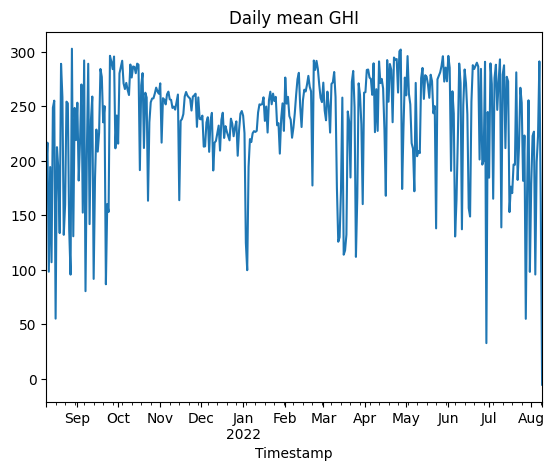

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
df_clean.set_index("Timestamp", inplace=True)
df_clean["GHI"].resample("D").mean().plot(title="Daily mean GHI")
plt.show()


4 Cleaning impact

In [12]:
grouped = df_clean.groupby("Cleaning")[["ModA","ModB"]].mean().reset_index()
display(grouped)


,Cleaning,ModA,ModB
0,0,232.323881,224.95509
1,1,306.610124,301.45000


5 Correlation heatmap

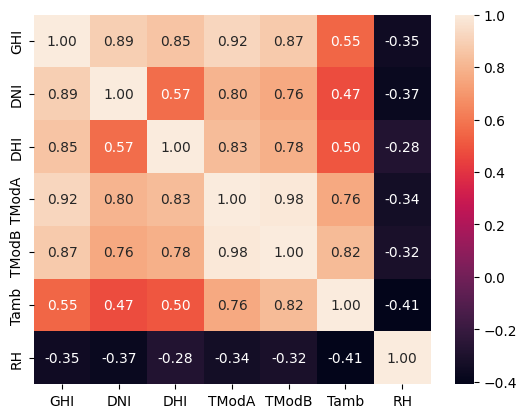

In [13]:
cols = ["GHI","DNI","DHI","TModA","TModB","Tamb","RH"]
sns.heatmap(df_clean[cols].corr(), annot=True, fmt=".2f")
plt.show()

6 Wind rose

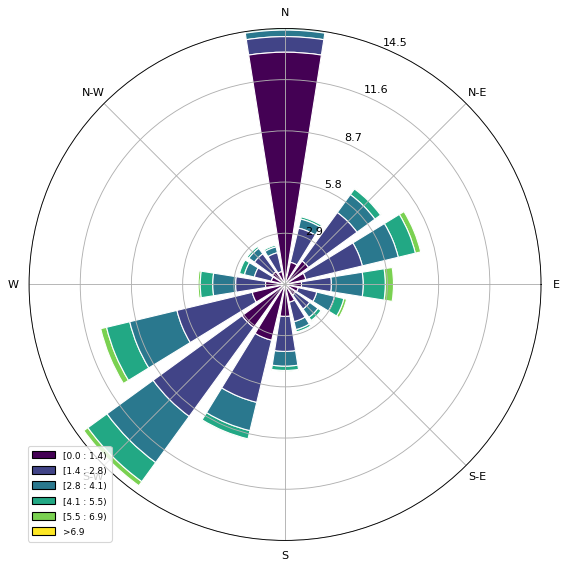

In [14]:
from windrose import WindroseAxes
ax = WindroseAxes.from_ax()
ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend()
plt.show()

In [16]:
df_clean.reset_index().to_csv("/home/abbie/Documents/data/benin-malanville.csv", index=False)
